In [4]:
import pandas as pd # For handling data tables
import numpy as np  # For math calculations
import matplotlib.pyplot as plt # For basic charts
import seaborn as sns # For beautiful professional charts
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("All tools are ready!")

All tools are ready!


In [5]:
# Load the data
df = pd.read_csv('train.csv')

# Let's see the 'Shape' of our data (Rows, Columns)
print(f"We have {df.shape[0]} rows and {df.shape[1]} columns.")

# View the first 5 rows to see what we are dealing with
df.head()

We have 8523 rows and 12 columns.


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [7]:
# 1. Fill Item_Weight with the Average
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

# 2. Fill Outlet_Size with the Most Common Size (Mode)
# [0] is used because .mode() returns a list
mode_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size)

# Check if we still have any missing values
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [8]:
# See the problem first
print("Before cleaning:")
print(df['Item_Fat_Content'].value_counts())

# Fix the typos
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'})

# See the result
print("\nAfter cleaning:")
print(df['Item_Fat_Content'].value_counts())

Before cleaning:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After cleaning:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


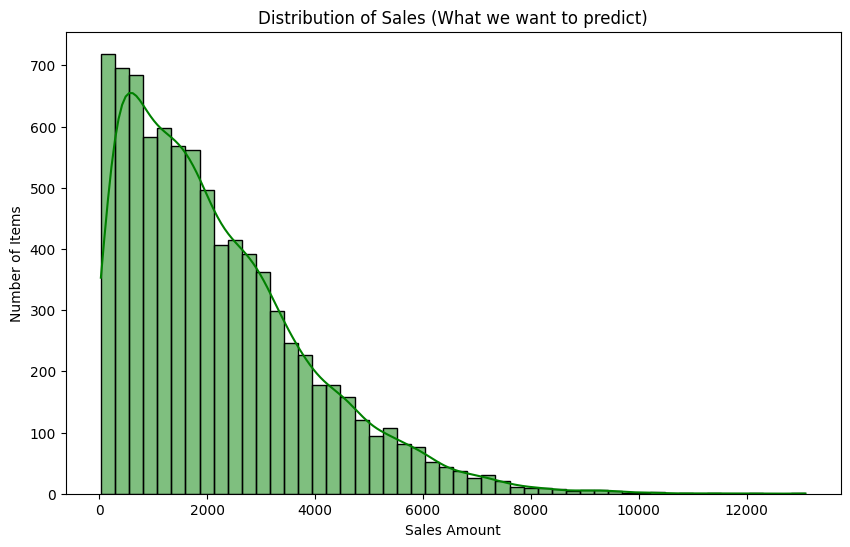

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['Item_Outlet_Sales'], bins=50, color='green', kde=True)
plt.title('Distribution of Sales (What we want to predict)')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Items')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize the translator
le = LabelEncoder()

# List of columns that are currently text (Objects)
text_columns = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Identifier']

# Loop through each column and turn text into numbers
for col in text_columns:
    df[col] = le.fit_transform(df[col])

# Let's see the transformation
print("Text has been converted to numbers!")
df.head()

Text has been converted to numbers!


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.20,1,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,NCD19,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [13]:
# 1. Define X (Input) and y (Output)
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])
y = df['Item_Outlet_Sales']

# 2. Split into Training (80%) and Testing (20%)
# We keep 20% aside to 'test' the model later, like a final exam.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")

Training Data: 6818 rows
Testing Data: 1705 rows


In [14]:
# 1. Create the model object
model = LinearRegression()

# 2. Train the model (The 'Fit' step)
model.fit(X_train, y_train)

# 3. Make predictions on our 'Exam' (X_test)
predictions = model.predict(X_test)

print("The model has finished learning from your data!")

The model has finished learning from your data!


Mean Absolute Error: 854.94
R-squared Score: 0.52


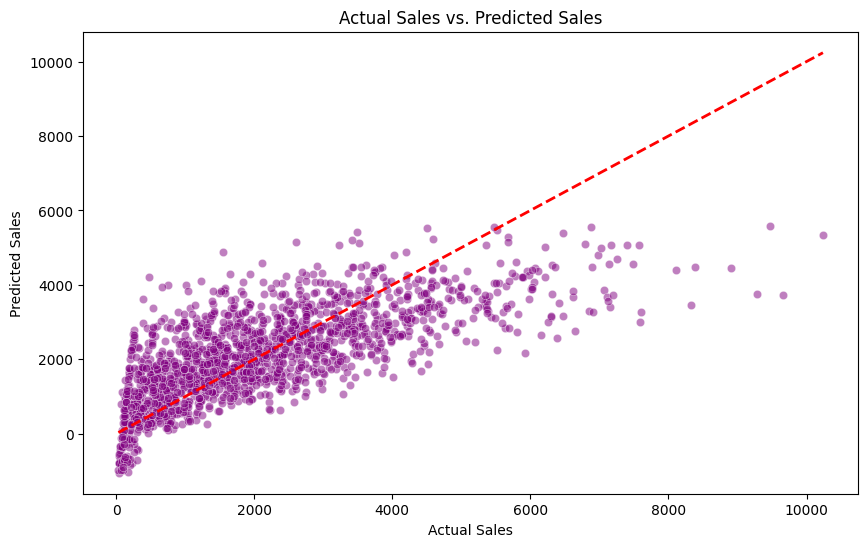

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Calculate the error (How far off were we?)
mae = mean_absolute_error(y_test, predictions)

# 2. Calculate the R2 Score (The 'Grade')
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

# 3. Visual Check: Actual vs Predicted
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual Sales vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

In [16]:
# 1. Clean the test data exactly like we did for the training data
test_df = pd.read_csv('test.csv')

# Fill missing values
test_df['Item_Weight'] = test_df['Item_Weight'].fillna(test_df['Item_Weight'].mean())
test_df['Outlet_Size'] = test_df['Outlet_Size'].fillna(test_df['Outlet_Size'].mode()[0])
test_df['Item_Fat_Content'] = test_df['Item_Fat_Content'].replace({'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'})

# Convert text to numbers (using the same 'le' encoder from before)
for col in text_columns:
    test_df[col] = le.fit_transform(test_df[col])

# 2. Drop the Identifier (keep it for the final file though!)
X_test_real = test_df.drop(columns=['Item_Identifier'])

# 3. Make the final predictions!
final_predictions = model.predict(X_test_real)

# 4. Save the results to a CSV file
output = pd.DataFrame({'Item_Identifier': test_df['Item_Identifier'], 'Predicted_Sales': final_predictions})
output.to_csv('Task1_Final_Predictions.csv', index=False)

print("Predictions saved to 'Task1_Final_Predictions.csv'!")

Predictions saved to 'Task1_Final_Predictions.csv'!
